In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
# Split into train and test
df = pd.read_csv("Data/sales.csv")
df.head()

,type,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,collab,date,num_posts,memberships_sold,pop,popcorn_large,popcorn_medium,popcorn_small,Alcohol,general_promo_likes,general_promo_shares,type_post,candy
0,Regular screening,291.0,7.0,141.0,2.0,472.46,95.0,No,04/09/2025,1,62.0,17.0,7.0,11.0,5.0,0.0,NaN,NaN,individual,0.0
1,Regular screening,222.0,4.0,118.0,2.0,598.42,108.0,No,08/09/2025,1,74.0,19.0,9.0,17.0,12.0,0.0,NaN,NaN,individual,0.0
2,Regular screening,228.0,11.0,129.0,2.0,633.93,128.0,No,11/09/2025,1,71.0,26.0,20.0,21.0,8.0,0.0,NaN,NaN,individual,0.0
3,Screen + Q&A,137.0,0.0,39.0,10.0,25.00,9.0,No,15/09/2025,2,3.0,3.0,1.0,0.0,1.0,0.0,89.0,33.0,both,0.0
4,Regular screening,194.0,0.0,41.0,2.0,237.92,53.0,No,18/09/2025,2,24.0,19.0,6.0,6.0,9.0,0.0,89.0,33.0,both,0.0


In [3]:
# Fill missing values with 0
df["general_promo_likes"] = df["general_promo_likes"].fillna(0)
df["general_promo_shares"] = df["general_promo_shares"].fillna(0)

# Covert date from string
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Date/month feature
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Sort
df_sorted = df.sort_values("date")

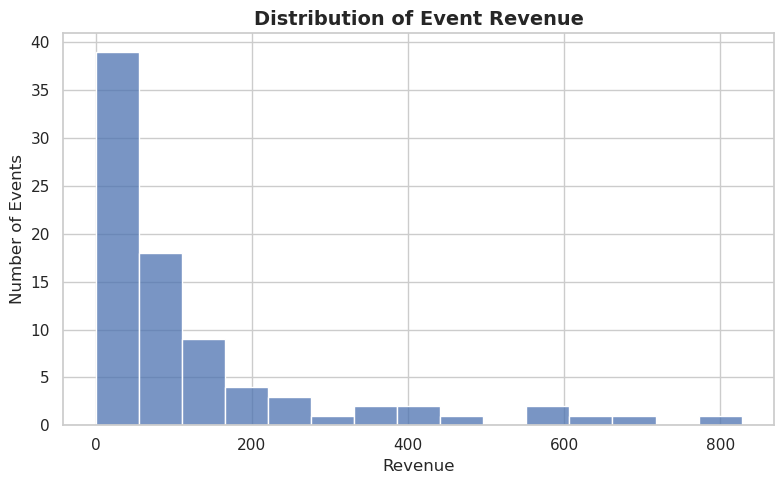

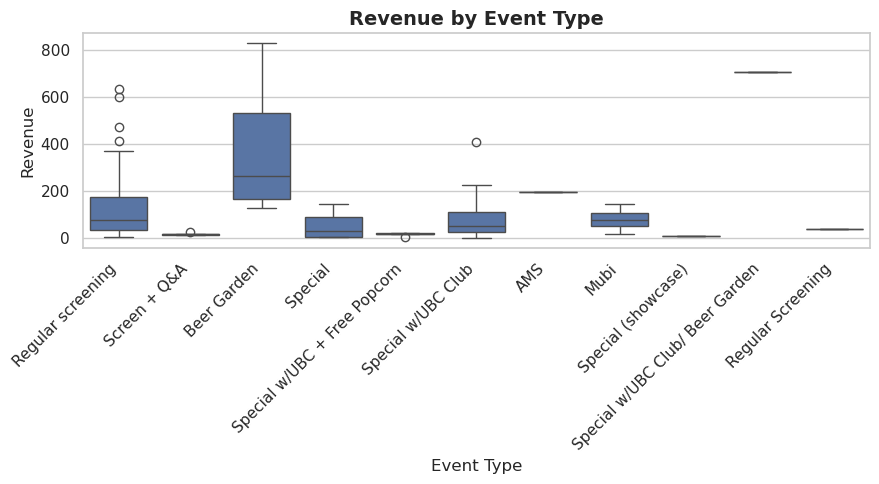

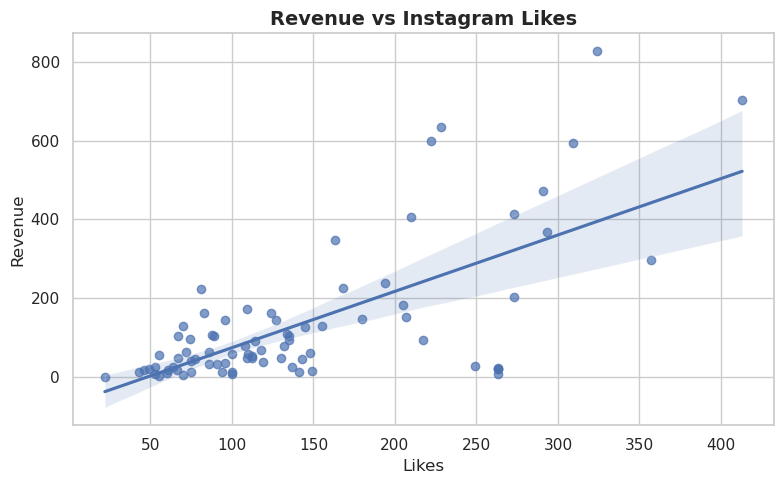

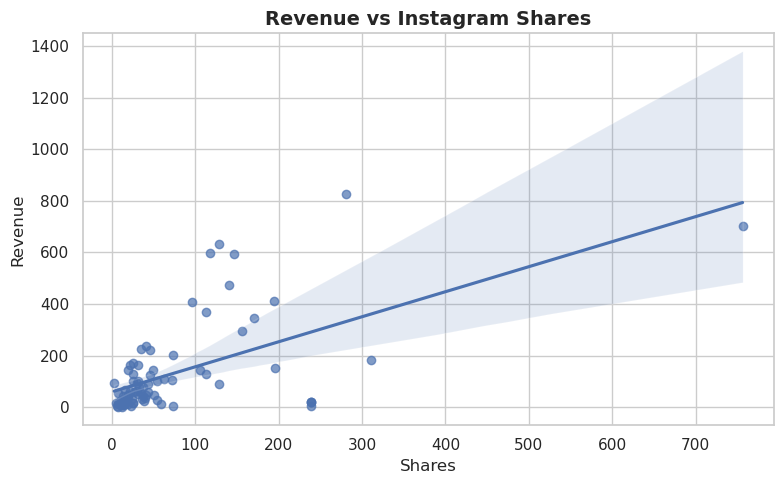

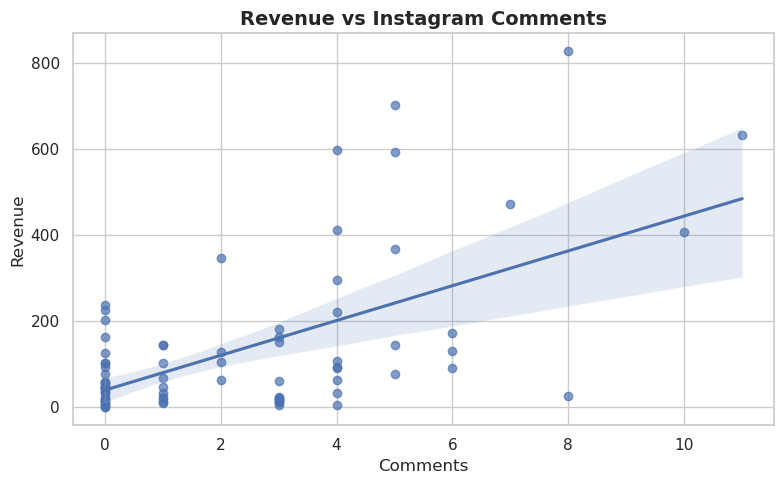

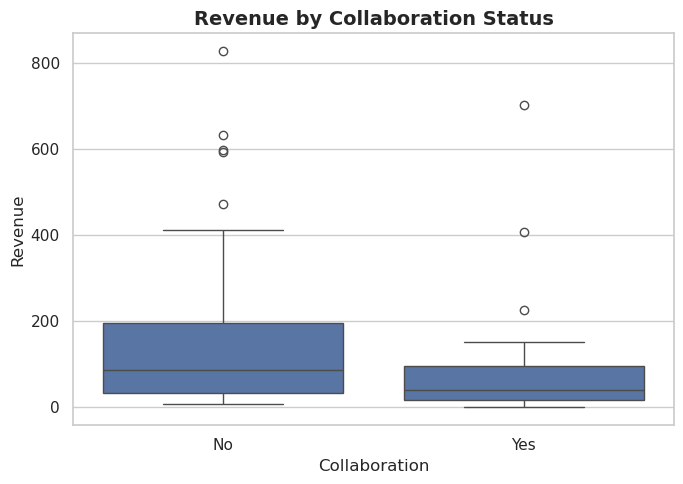

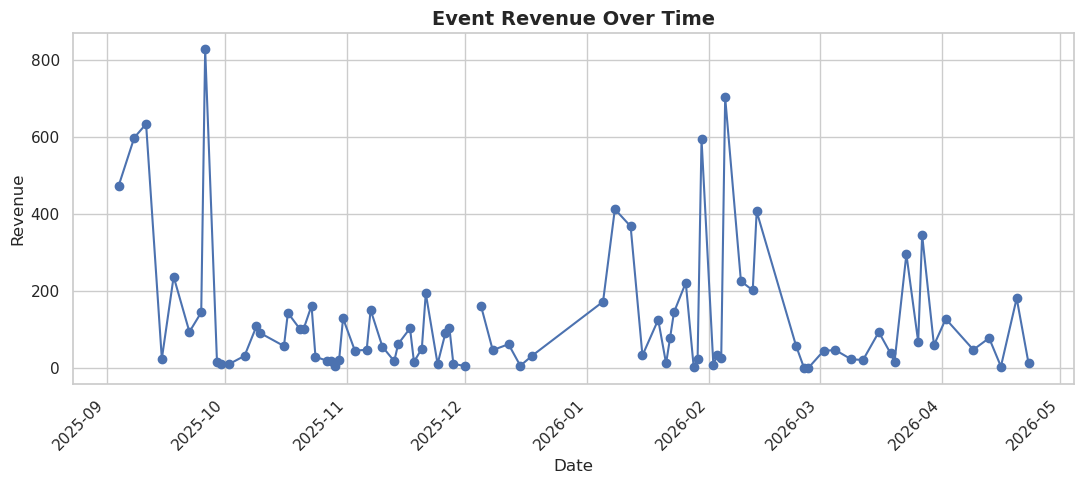

In [4]:
# EDA Visualizations
sns.set_theme(style="whitegrid")

def finish_plot(title, xlabel=None, ylabel=None, rotate_x=False):
    plt.title(title, fontsize=14, fontweight="bold")
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 1. Revenue Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["revenue"], bins=15)
finish_plot(
    title="Distribution of Event Revenue",
    xlabel="Revenue",
    ylabel="Number of Events"
)


# 2. Revenue by Event Type
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="type", y="revenue")
finish_plot(
    title="Revenue by Event Type",
    xlabel="Event Type",
    ylabel="Revenue",
    rotate_x=True
)


# 3. Revenue vs Likes
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="likes", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Likes",
    xlabel="Likes",
    ylabel="Revenue"
)


# 4. Revenue vs Shares
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_shares", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Shares",
    xlabel="Shares",
    ylabel="Revenue"
)


# 5. Revenue vs Comments
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_comments", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Comments",
    xlabel="Comments",
    ylabel="Revenue"
)


# 6. Revenue by Collaboration
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="collab", y="revenue")
finish_plot(
    title="Revenue by Collaboration Status",
    xlabel="Collaboration",
    ylabel="Revenue"
)


# 7. Revenue Over Time
plt.figure(figsize=(11, 5))
plt.plot(df_sorted["date"], df_sorted["revenue"], marker="o")
finish_plot(
    title="Event Revenue Over Time",
    xlabel="Date",
    ylabel="Revenue",
    rotate_x=True
)

<Axes: >

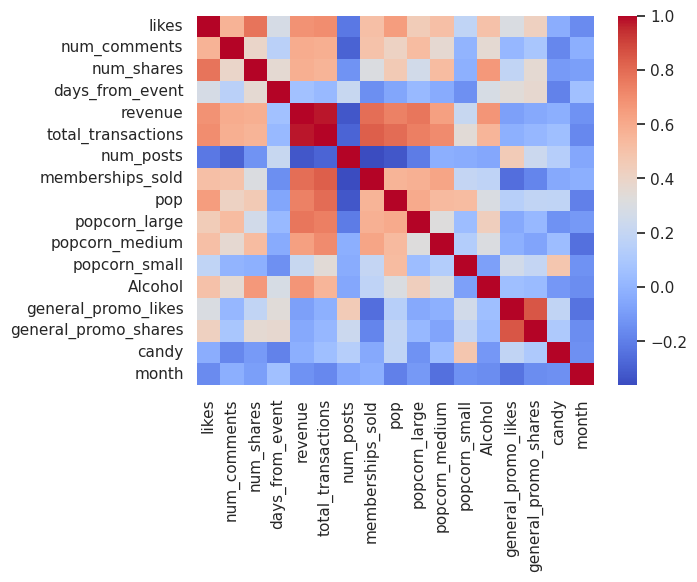

In [5]:
# Correlation mapping
numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

<Axes: xlabel='total_engagement', ylabel='revenue'>

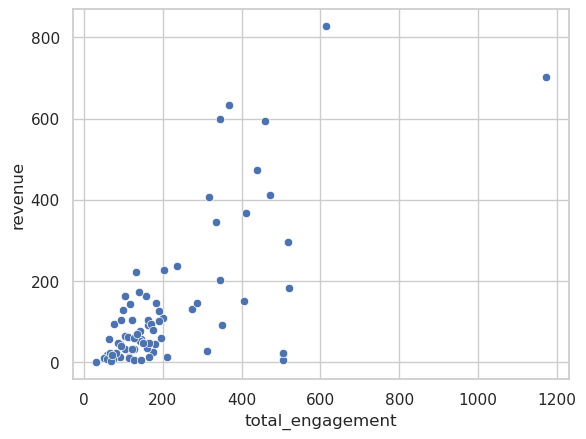

In [6]:
# Feature Engineering 
df["total_engagement"] = (
    df["likes"]
    + df["num_comments"]
    + df["num_shares"]
)

sns.scatterplot(
    data=df,
    x="total_engagement",
    y="revenue"
)

In [7]:
# Split data 
train_df, test_df = train_test_split(df, test_size=0.20, random_state=123)
train_df.head()

,type,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,collab,date,num_posts,...,popcorn_medium,popcorn_small,Alcohol,general_promo_likes,general_promo_shares,type_post,candy,month,day_of_week,total_engagement
9,Regular screening,94.0,3.0,16.0,2.0,11.83,4.0,No,2025-09-30,2,...,0.0,0.0,0.0,82.0,14.0,both,0.0,9,Tuesday,113.0
78,Regular screening,148.0,3.0,43.0,2.0,60.32,16.0,No,2026-03-30,2,...,5.0,1.0,0.0,131.0,58.0,both,0.0,3,Monday,194.0
79,Special w/UBC Club,70.0,2.0,26.0,4.0,128.32,27.0,Yes,2026-04-02,2,...,8.0,0.0,3.0,131.0,58.0,both,0.0,4,Thursday,98.0
28,Regular screening,55.0,0.0,7.0,2.0,56.15,9.0,No,2025-11-10,2,...,3.0,3.0,0.0,53.0,14.0,both,4.0,11,Monday,62.0
60,Special w/UBC Club,249.0,8.0,54.0,5.0,27.66,7.0,Yes,2026-02-04,2,...,4.0,2.0,0.0,108.0,51.0,both,0.0,2,Wednesday,311.0


In [8]:
# Split target value
X_train = train_df.drop(columns=["revenue"])
y_train = train_df["revenue"]

X_test = test_df.drop(columns=["revenue"])
y_test = test_df["revenue"]

In [9]:
train_df.describe()

,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,date,num_posts,memberships_sold,pop,popcorn_large,popcorn_medium,popcorn_small,Alcohol,general_promo_likes,general_promo_shares,candy,month,total_engagement
count,65.000000,65.000000,65.000000,65.000000,67.000000,67.000000,68,68.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,68.000000,68.000000,67.000000,68.000000,65.000000
mean,143.492308,2.261538,79.861538,3.230769,132.639104,25.835821,2025-12-21 21:31:45.882353,1.867647,8.567164,8.522388,3.567164,4.686567,2.447761,3.776119,93.647059,47.632353,0.731343,6.544118,225.615385
min,22.000000,0.000000,3.000000,1.000000,0.000000,0.000000,2025-09-04 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,29.000000
25%,77.000000,0.000000,20.000000,2.000000,21.000000,6.000000,2025-10-26 00:00:00,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,56.000000,13.000000,0.000000,2.000000,105.000000
50%,114.000000,1.000000,38.000000,2.000000,57.980000,12.000000,2025-12-06 00:00:00,2.000000,3.000000,5.000000,1.000000,3.000000,0.000000,0.000000,81.000000,28.000000,0.000000,9.000000,150.000000
75%,205.000000,4.000000,113.000000,3.000000,148.555000,27.500000,2026-02-14 18:00:00,2.000000,7.000000,11.000000,4.500000,5.500000,2.500000,0.000000,118.000000,52.000000,0.000000,10.000000,335.000000
max,413.000000,11.000000,756.000000,13.000000,827.540000,128.000000,2026-04-23 00:00:00,3.000000,74.000000,39.000000,26.000000,36.000000,63.000000,77.000000,288.000000,239.000000,10.000000,12.000000,1174.000000
std,84.257812,2.538928,114.441289,2.422352,184.630017,32.141542,NaN,0.419823,15.404863,9.178958,5.535625,6.348965,7.958764,13.666838,69.297060,62.638242,2.019467,4.115619,189.728481
